In [1]:
import os
import copy

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, ConcatDataset
import torchvision.transforms as transforms

import timm
from timm.models.vision_transformer import VisionTransformer

In [2]:
class AffectNetClassificationDataset(Dataset):
    """AffectNet classification dataset.

    Expects images in `image_dir` and `.npy` annotation files in `annotation_dir`.
    Annotations are read once into memory for fast lookup.
    Returns a tuple: (image_tensor, { 'arousal', 'valence', 'expression' }).
    """
    def __init__(self, image_dir, annotation_dir, transform=None):
        self.image_dir = image_dir
        self.annotation_dir = annotation_dir
        self.image_files = sorted(os.listdir(image_dir))
        self.transform = transform
        self.annotations = {}

        # Add tqdm progress bar here
        annotation_files = [file for file in os.listdir(annotation_dir) if file.endswith('.npy')]
        for file in tqdm(annotation_files, desc="Loading AffectNet annotation files"):
            key = file.split('.')[0]
            npy_path = os.path.join(annotation_dir, file)
            self.annotations[key] = np.load(npy_path, allow_pickle=True)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        img_id = os.path.splitext(img_name)[0]
        aro = self.annotations.get(f'{img_id}_aro', np.array([-1]))
        val = self.annotations.get(f'{img_id}_val', np.array([-1]))
        exp = self.annotations.get(f'{img_id}_exp', np.array([-1]))
        aro = aro.item() if aro.size == 1 else aro
        val = val.item() if val.size == 1 else val
        exp = exp.item() if exp.size == 1 else exp

        labels = {
            'arousal': aro,
            'valence': val,
            'expression': exp
        }

        return image, labels

In [3]:
train_data = torch.load("../datasets/AffectNet/AffectNet-torch/train_dataset.pt", weights_only=False)
val_data = torch.load("../datasets/AffectNet/AffectNet-torch/test_dataset.pt", weights_only=False)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # random crop & scale
    transforms.RandomHorizontalFlip(p=0.5),               # flip horizontally
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # color augmentation
    transforms.RandomRotation(15),                        # small rotations
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # deterministic resize for val/test
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
train_data.transform = train_transform
val_data.transform = val_transform
train_data.image_dir = "../datasets/AffectNet/AffectNet-images/train_set/images"
val_data.image_dir = '../datasets/AffectNet/AffectNet-images/val_set/images'
train_data = ConcatDataset([train_data, val_data])

In [4]:
import timm
import torch
import copy

def create_mae_model_from_timm(new_depth=6):
    # Step 1: Create ViT encoder with same architecture, without downloading
    encoder = timm.create_model(
        'vit_base_patch16_224',
        pretrained=False,  # Prevents downloading
        img_size=224,
        patch_size=16,
        embed_dim=768,
        depth=new_depth,
        num_heads=12,
        mlp_ratio=4.0
    )

    # Step 2: Load local checkpoint (make sure it's compatible with your encoder config)
    ckpt_path = '../models/vit_base_patch16_224.pth'
    state_dict = torch.load(ckpt_path, map_location='cpu')
    
    # If needed, remove "module." prefix (some checkpoints have it)
    if any(k.startswith("module.") for k in state_dict.keys()):
        state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

    # Load weights
    missing_keys, unexpected_keys = encoder.load_state_dict(state_dict, strict=False)
    print("✅ Loaded encoder weights.")
    print(f"Missing keys: {len(missing_keys)} | Unexpected keys: {len(unexpected_keys)}")

    return encoder


class SimpleMAE(torch.nn.Module):
    def __init__(
        self, 
        encoder,
        decoder_embed_dim=512,
        decoder_depth=8,
        decoder_num_heads=16,
        mask_ratio=0.75,
        norm_pix_loss=True
    ):
        super().__init__()
        self.encoder = encoder
        self.img_size = encoder.patch_embed.img_size[0]
        self.patch_size = encoder.patch_embed.patch_size[0]
        self.embed_dim = encoder.embed_dim
        self.num_patches = (self.img_size // self.patch_size) ** 2
        self.mask_token = torch.nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.decoder_embed = torch.nn.Linear(self.embed_dim, decoder_embed_dim, bias=True)
        self.decoder_pos_embed = torch.nn.Parameter(torch.zeros(1, self.num_patches + 1, decoder_embed_dim))
        self.decoder_blocks = torch.nn.ModuleList([
            timm.models.vision_transformer.Block(
                decoder_embed_dim, decoder_num_heads, 4.0
            ) for _ in range(decoder_depth)
        ])
        
        self.decoder_norm = torch.nn.LayerNorm(decoder_embed_dim)
        self.decoder_pred = torch.nn.Linear(
            decoder_embed_dim, self.patch_size**2 * 3, bias=True
        )
        
        self.mask_ratio = mask_ratio
        self.norm_pix_loss = norm_pix_loss
        self.initialize_weights()
    
    def initialize_weights(self):
        torch.nn.init.normal_(self.mask_token, std=0.02)
        torch.nn.init.normal_(self.decoder_pos_embed, std=0.02)
        torch.nn.init.xavier_uniform_(self.decoder_embed.weight)
        torch.nn.init.zeros_(self.decoder_embed.bias)
        torch.nn.init.xavier_uniform_(self.decoder_pred.weight)
        torch.nn.init.zeros_(self.decoder_pred.bias)
    
    def random_masking(self, x, mask_ratio):
        N, L, D = x.shape
        len_keep = int(L * (1 - mask_ratio))
        noise = torch.rand(N, L, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(
            x, dim=1, 
            index=ids_keep.unsqueeze(-1).repeat(1, 1, D)
        )
        mask = torch.ones([N, L], device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)
        
        return x_masked, mask, ids_restore
    
    def forward_encoder(self, x, mask_ratio):
        patches = self.encoder.patch_embed(x)
        patches = patches + self.encoder.pos_embed[:, 1:, :]
        patches_masked, mask, ids_restore = self.random_masking(patches, mask_ratio)
        cls_token = self.encoder.cls_token + self.encoder.pos_embed[:, :1, :]
        cls_tokens = cls_token.expand(patches_masked.shape[0], -1, -1)
        x = torch.cat((cls_tokens, patches_masked), dim=1)
        for blk in self.encoder.blocks:
            x = blk(x)
        x = self.encoder.norm(x)
        
        return x, mask, ids_restore
    
    def forward_decoder(self, x, ids_restore):
        x = self.decoder_embed(x)
        mask_tokens = self.mask_token.repeat(
            x.shape[0], ids_restore.shape[1] + 1 - x.shape[1], 1
        )
        x_ = x[:, 1:, :]
        x_ = torch.cat([x_, mask_tokens], dim=1)
        x_ = torch.gather(
            x_, dim=1,
            index=ids_restore.unsqueeze(-1).repeat(1, 1, x.shape[2])
        )
        x = torch.cat([x[:, :1, :], x_], dim=1)
        x = x + self.decoder_pos_embed
        for blk in self.decoder_blocks:
            x = blk(x)
        x = self.decoder_norm(x)
        x = self.decoder_pred(x)
        x = x[:, 1:, :]
        
        return x
    
    def patchify(self, imgs):
        p = self.patch_size
        h = w = self.img_size // p
        x = imgs.reshape(shape=(imgs.shape[0], 3, h, p, w, p))
        x = torch.einsum('nchpwq->nhwpqc', x)
        x = x.reshape(shape=(imgs.shape[0], h * w, p**2 * 3))
        
        return x
    
    def unpatchify(self, x):
        p = self.patch_size
        h = w = int(x.shape[1]**0.5)
        assert h * w == x.shape[1]
        x = x.reshape(shape=(x.shape[0], h, w, p, p, 3))
        x = torch.einsum('nhwpqc->nchpwq', x)
        imgs = x.reshape(shape=(x.shape[0], 3, h * p, w * p))
        
        return imgs
    
    def forward_loss(self, imgs, pred, mask):
        target = self.patchify(imgs)
        if self.norm_pix_loss:
            mean = target.mean(dim=-1, keepdim=True)
            var = target.var(dim=-1, keepdim=True)
            target = (target - mean) / (var + 1.e-6)**0.5
        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)
        loss = (loss * mask).sum() / mask.sum()
        
        return loss
    
    def forward(self, imgs, mask_ratio=None):
        if mask_ratio is None:
            mask_ratio = self.mask_ratio
        latent, mask, ids_restore = self.forward_encoder(imgs, mask_ratio)
        pred = self.forward_decoder(latent, ids_restore)
        loss = self.forward_loss(imgs, pred, mask)
        return loss, pred, mask, ids_restore

In [5]:
def train_mae_model(
    model,
    train_dataset,
    val_dataset,
    num_epochs=20,
    batch_size=64,
    lr=1e-4,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    save_dir='./checkpoints'
):
    """Train a MAE model with reconstruction loss.

    - Saves best weights and per-epoch checkpoints.
    - Logs and plots train/val loss curves.
    - Saves 3-sample reconstruction grid after each epoch to ./mae_reconstructions.
    """
    import time, random

    os.makedirs(save_dir, exist_ok=True)
    recon_save_dir = './mae_reconstructions'
    os.makedirs(recon_save_dir, exist_ok=True)
    checkpoint = torch.load("../checkouts/small_mae/model_epoch_18.pth", map_location="cpu", weights_only=False)
    mae_model.load_state_dict(checkpoint['model_state_dict'])
    
    device = torch.device(device)
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=os.cpu_count() or 4, pin_memory=(device.type=='cuda'), persistent_workers=True)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=os.cpu_count() or 4, pin_memory=(device.type=='cuda'), persistent_workers=True)

    best_val_loss = float('inf')
    train_losses, val_losses = [], []
    start_epoch = 18
    for epoch in range(start_epoch, num_epochs):
        epoch_start_time = time.time()
        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        model.train()
        running_loss = 0.0

        train_pbar = tqdm(train_loader, desc='Training', leave=False)
        for images, _ in train_pbar:
            images = images.to(device)

            loss, _, _, _ = model(images)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            train_pbar.set_postfix(loss=loss.item())

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # ---- Validation ----
        model.eval()
        val_loss = 0.0
        val_pbar = tqdm(val_loader, desc='Validation', leave=False)
        with torch.no_grad():
            for images, _ in val_pbar:
                images = images.to(device)
                loss, _, _, _ = model(images)
                val_loss += loss.item() * images.size(0)
                val_pbar.set_postfix(loss=loss.item())

        epoch_val_loss = val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        epoch_duration = time.time() - epoch_start_time

        print(f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Duration: {epoch_duration:.2f}s")

        # ---- Save best model ----
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(best_model_wts, os.path.join(save_dir, 'best_model.pth'))
            print("✅ Best model saved!")

        # ---- Save current epoch checkpoint with metadata ----
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': epoch_train_loss,
            'training_duration': epoch_duration,
        }
        torch.save(checkpoint, os.path.join(save_dir, f'model_epoch_{epoch+1}.pth'))

        # ---- Save 3-image reconstruction grid ----
        try:
            model.eval()
            with torch.no_grad():
                num_samples = min(3, len(val_dataset))
                sample_indices = random.sample(range(len(val_dataset)), num_samples) if len(val_dataset) >= 3 else list(range(num_samples))
                sample_imgs = [val_dataset[i][0] for i in sample_indices]
                sample_batch = torch.stack(sample_imgs).to(device)

                _, pred, _, _ = model(sample_batch)
                recon_imgs = model.unpatchify(pred)

                def _denorm(x):
                    x = x.detach().cpu()
                    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
                    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
                    x = x * std + mean
                    x = torch.clamp(x, 0, 1)
                    return x

                originals = _denorm(sample_batch)
                reconstructions = _denorm(recon_imgs)

                fig, axes = plt.subplots(2, num_samples, figsize=(4 * num_samples, 6))
                for i in range(num_samples):
                    axes[0, i].imshow(originals[i].permute(1, 2, 0).numpy())
                    axes[0, i].axis('off')
                    axes[0, i].set_title('Original')
                    axes[1, i].imshow(reconstructions[i].permute(1, 2, 0).numpy())
                    axes[1, i].axis('off')
                    axes[1, i].set_title('Reconstruction')

                plt.tight_layout()
                recon_path = os.path.join(recon_save_dir, f'recontruction_epoch_{epoch+1}.png')
                plt.savefig(recon_path)
                plt.close(fig)
        except Exception as e:
            print(f"⚠️ Failed to save reconstruction grid: {e}")

        # ---- Plot loss curve ----
        plt.figure(figsize=(10, 5))
        plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
        plt.plot(range(1, len(val_losses)+1), val_losses, label='Val Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('MAE Training Loss Curve')
        plt.legend()
        plt.grid(True)
        plt.savefig(os.path.join(save_dir, f'loss_plot_epoch_{epoch+1}.png'))
        plt.close()

        # ---- Save loss values to text ----
        with open(os.path.join(save_dir, 'loss_log.txt'), 'a') as f:
            f.write(f'Epoch {epoch+1}: Train Loss = {epoch_train_loss:.4f}, Val Loss = {epoch_val_loss:.4f}, Duration = {epoch_duration:.2f}s\n')

    print("✅ Training complete!")
    return train_losses, val_losses

In [ ]:
# Initialize encoder and MAE model, optionally load weights, then train.
encoder = create_mae_model_from_timm(new_depth=6)
mae_model = SimpleMAE(encoder)
print(sum(p.numel() for p in mae_model.parameters()))
# Step 4 (optional): Move to GPU if available
mae_model.to('cuda' if torch.cuda.is_available() else 'cpu')
train_losses, val_losses = train_mae_model(
    model=mae_model,
    train_dataset=train_data,
    val_dataset=val_data,
    num_epochs=35,
    batch_size=64,
    save_dir='../checkouts/small_mae'
)


✅ Loaded encoder weights.
Missing keys: 0 | Unexpected keys: 72
Loss: 0.1765


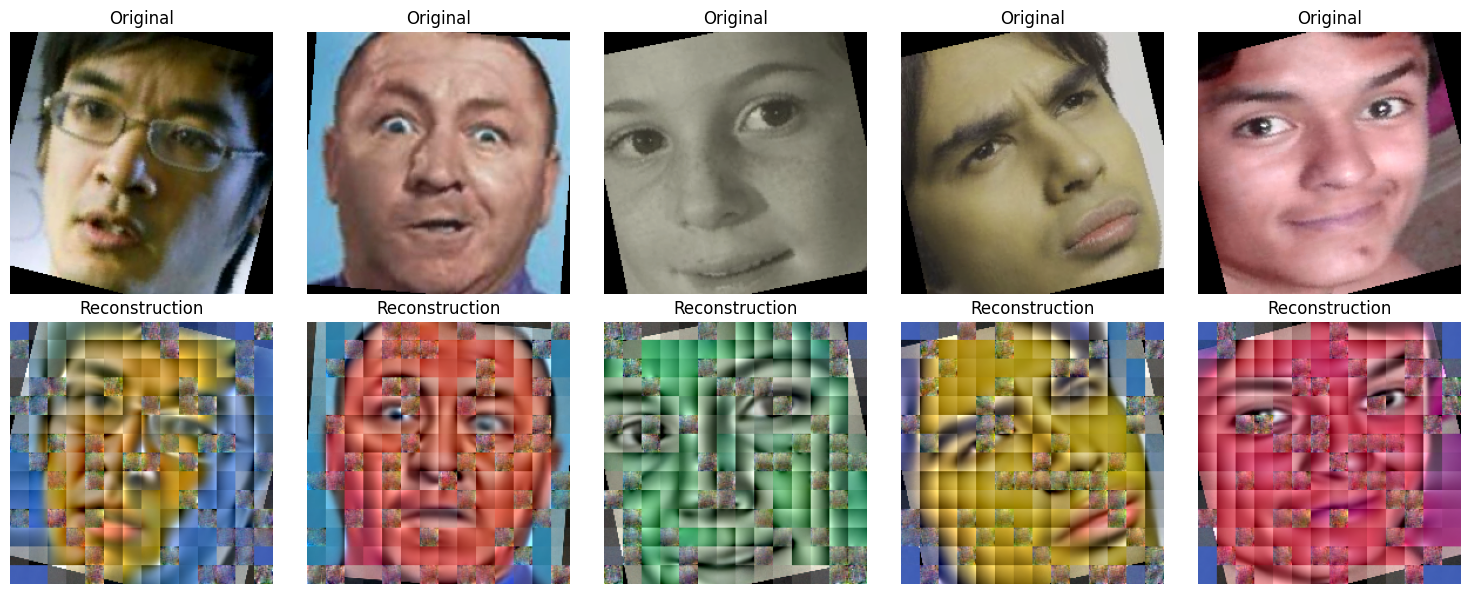

In [10]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
import numpy as np

# 1. Create and load the model
encoder = create_mae_model_from_timm(new_depth=6)
model = SimpleMAE(encoder)
model.load_state_dict(torch.load('../checkouts/small_mae/model_epoch_35.pth', map_location='cpu')["model_state_dict"])  # Replace with your real path
model.eval()
model.to('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Create DataLoader for testing
from torch.utils.data import DataLoader

test_loader = DataLoader(train_data, batch_size=5, shuffle=True)  # small batch for visualization

# 3. Utility to show original and reconstructed images
def show_image_comparison(original_imgs, reconstructed_imgs):
    """Visualize original and reconstructed images side-by-side."""
    original_imgs = original_imgs.cpu()
    reconstructed_imgs = reconstructed_imgs.cpu()
    fig, axes = plt.subplots(2, len(original_imgs), figsize=(15, 6))

    for i in range(len(original_imgs)):
        # Original
        img = original_imgs[i].permute(1, 2, 0).numpy()
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # unnormalize
        img = np.clip(img, 0, 1)
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
        axes[0, i].set_title("Original")

        # Reconstructed
        img = reconstructed_imgs[i].permute(1, 2, 0).numpy()
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # unnormalize
        img = np.clip(img, 0, 1)
        axes[1, i].imshow(img)
        axes[1, i].axis('off')
        axes[1, i].set_title("Reconstruction")

    plt.tight_layout()
    plt.show()

# 4. Run model on sample batch
device = 'cuda' if torch.cuda.is_available() else 'cpu'

with torch.no_grad():
    for batch in test_loader:
        imgs, _ = batch
        imgs = imgs.to(device)
        
        loss, pred, mask, ids_restore = model(imgs)
        print(f"Loss: {loss.item():.4f}")

        # Get reconstructed images
        recon_imgs = model.unpatchify(pred)
        
        # Show original vs reconstructed
        show_image_comparison(imgs, recon_imgs)
        break  # just one batch for testing


## Small MAE Pretraining

- Build a small MAE using a ViT-B/16 encoder from `timm`.
- Train with reconstruction loss on AffectNet.
- Visualize reconstructions.

Contents:
- Dataset and transforms
- Encoder/decoder definition
- Training loop and checkpointing
- Visualization utilities
